### jupyter version of TemporalVAE_LR_PCA_RF_directlyPredictOn_mouseStereo.py
### for Figure3 D&E


In [1]:
# -*-coding:utf-8 -*-
import os
if os.getcwd().split("/")[-1] != "TemporalVAE":
    os.chdir("..")
import sys
sys.path.append(os.getcwd())

import anndata as ad
import pandas as pd
from collections import Counter
from utils.utils_DandanProject import geneId_geneName_dic, predict_newData_preprocess_df, preprocessData_and_dropout_some_donor_or_gene
from utils.utils_Dandan_plot import calculate_real_predict_corrlation_score, plot_psupertime_density
import time
import logging
from utils.logging_system import LogHelper
import yaml
from utils.utils_Dandan_plot import plot_violin_240223

### define functions

In [2]:
def plot_compare_corr_boxplot(save_path):
    # ---------- pretrain a model (TemporalVAE, LR, PCA, RF) on mouse atlas data, directly predict on mouse stereo data -----------------------
    from utils.utils_Dandan_plot import plot_boxplot_from_dic
    # ---------- pretrain a model (TemporalVAE, LR, PCA, RF) on mouse atlas data, directly predict on mouse stereo data -----------------------
    file_name = f"{save_path}/temporalVAE_result_df.csv"
    data_pd = pd.read_csv(file_name)
    VAE = calculate_real_predict_corrlation_score(data_pd["time"], data_pd["pseudotime"], only_str=False)

    file_name = f"{save_path}/linearRegression_result_df.csv"
    data_pd = pd.read_csv(file_name)
    LR = calculate_real_predict_corrlation_score(data_pd["time"], data_pd["pseudotime"], only_str=False)

    file_name = f"{save_path}/PCA_result_df.csv"
    data_pd = pd.read_csv(file_name)
    PCA = calculate_real_predict_corrlation_score(data_pd["time"], data_pd["pseudotime"], only_str=False)

    file_name = f"{save_path}/randomForest_result_df.csv"
    data_pd = pd.read_csv(file_name)
    RF = calculate_real_predict_corrlation_score(data_pd["time"], data_pd["pseudotime"], only_str=False)
    # 构建数据，确保按照VAE、LR、PCA的顺序
    data = {
        'Method': ['TemporalVAE', 'TemporalVAE', 'LR', 'LR', 'PCA', 'PCA', 'RF', 'RF'],
        'Correlation Type': ['Spearman', 'Pearson', 'Spearman', 'Pearson', 'Spearman', 'Pearson', 'Spearman', 'Pearson'],
        'Value': [VAE[1]['spearman'].correlation, VAE[1]['pearson'].correlation,
                  LR[1]['spearman'].correlation, LR[1]['pearson'].correlation,
                  PCA[1]['spearman'].correlation, PCA[1]['pearson'].correlation,
                  RF[1]['spearman'].correlation, RF[1]['pearson'].correlation]
    }
    data["Value"] = [abs(_i) if _i < 0 else _i for _i in data["Value"]]
    plot_boxplot_from_dic(data, legend_loc="upper right")


def directly_predict_on_vae(query_adata, save_path, checkpoint_file, config):
    method = "temporalVAE"
    import torch
    torch.set_float32_matmul_precision('high')

    # 2024-02-23 14:26:17 add only predict on stereo data
    checkpoint = torch.load(checkpoint_file, map_location='cpu')
    # 去掉每层名字前面的 "model."
    state_dict = checkpoint['state_dict']
    new_state_dict = {}
    for key, value in state_dict.items():
        # 去掉前缀 "model."
        if key.startswith('model.'):
            key = key[6:]
        new_state_dict[key] = value
    # MyVAEModel = vae_models[config['model_params']['name']](**config['model_params'])
    config['model_params']['in_channels'] = query_adata.X.shape[1]  # the number of features

    from model_master import vae_models
    MyVAEModel = vae_models["SuperviseVanillaVAE_regressionClfDecoder_mouse_noAdversarial"](**config['model_params'])
    MyVAEModel.load_state_dict(new_state_dict)
    MyVAEModel.eval()

    from utils.GPU_manager_pytorch import check_memory, auto_select_gpu_and_cpu
    check_memory()
    # device = auto_select_gpu_and_cpu()
    device = auto_select_gpu_and_cpu(free_thre=5, max_attempts=100000000)  # device: e.g. "cuda:0"
    from pytorch_lightning import Trainer, seed_everything
    runner = Trainer(devices=[int(device.split(":")[-1])])
    seed_everything(config['exp_params']['manual_seed'], True)
    #
    x_sc = torch.tensor(query_adata.X, dtype=torch.get_default_dtype()).t()
    data_x = [[x_sc[:, i], 0, 0] for i in range(x_sc.shape[1])]

    # predict batch size will not influence the training
    from model_master.dataset import SupervisedVAEDataset_onlyPredict
    from model_master.experiment import VAEXperiment
    data_predict = SupervisedVAEDataset_onlyPredict(predict_data=data_x, predict_batch_size=len(data_x))

    experiment = VAEXperiment(MyVAEModel, config['exp_params'])
    # z=experiment.predict_step(data_predict,1)
    train_result = runner.predict(experiment, data_predict)
    pseudoTime_directly_predict_by_pretrained_model = train_result[0][0]
    pseudoTime_directly_predict_by_pretrained_model_df = pd.DataFrame(pseudoTime_directly_predict_by_pretrained_model, columns=["pseudotime_by_preTrained_mouseAtlas_model"])
    pseudoTime_directly_predict_by_pretrained_model_df.index = query_adata.obs_names
    from utils.utils_DandanProject import denormalize
    pseudoTime_directly_predict_by_pretrained_model_df["physical_pseudotime_by_preTrained_mouseAtlas_model"] = pseudoTime_directly_predict_by_pretrained_model_df[
        "pseudotime_by_preTrained_mouseAtlas_model"].apply(denormalize, args=(8.5, 18.75, -5, 5))
    mu_predict_by_pretrained_model = train_result[0][1].cpu().numpy()

    cell_time_stereo = pd.concat([query_adata.obs, pseudoTime_directly_predict_by_pretrained_model_df], axis=1)

    color_dic = plot_violin_240223(cell_time_stereo, save_path,real_attr="time")
    # print(color_dic)
    from utils.utils_Dandan_plot import plot_umap_240223
    plot_umap_240223(mu_predict_by_pretrained_model, cell_time_stereo, color_dic, save_path, attr_str="time")

    color_dic = {'Brain': "#FA8072", 'Connective tissue': "#32CD32",
                 'Muscle': "#4169E1", 'Cavity': "#FFA500",
                 'Liver': "#20B2AA", 'Spinal cord': "#FF4500",
                 'Meninges': "#EE82EE", 'Jaw and tooth': "#8B4513",
                 'Cartilage primordium': "#8E44AD", 'Epidermis': "#AD9BA5"}
    plot_umap_240223(mu_predict_by_pretrained_model, cell_time_stereo, color_dic, save_path, attr_str="celltype_update")
    cell_time_stereo["pseudotime"] = cell_time_stereo["physical_pseudotime_by_preTrained_mouseAtlas_model"]
    print("Final corr:", calculate_real_predict_corrlation_score(cell_time_stereo["time"], cell_time_stereo["pseudotime"]))

    cell_time_stereo.to_csv(f'{save_path}/{method}_result_df.csv', index=True)
    print(f"test result save at {save_path}/{method}_result_df.csv")

    plot_psupertime_density(cell_time_stereo, save_path=save_path, label_key="time", psupertime_key="pseudotime", method=method)
    print(f"Finish {method} train on baseline data and predict on query data.")


# ---------------------------------------- train LR model -----------------------------------------------------
def train_LR_model(atlas_sc_expression_df, cell_time_atlas, query_adata, save_path, ):
    method = "linearRegression"
    from sklearn.linear_model import LinearRegression
    # use one donor as test set, other as train set
    adata_atlas = ad.AnnData(X=atlas_sc_expression_df, obs=cell_time_atlas)
    train_adata = adata_atlas.copy()
    model = LinearRegression()
    model.fit(train_adata.X, train_adata.obs["time"])
    query_predictions = model.predict(query_adata.X)
    query_result_df = pd.DataFrame({"time": query_adata.obs["time"], "pseudotime": query_predictions})

    print("Final corr:", calculate_real_predict_corrlation_score(query_result_df["time"], query_result_df["pseudotime"]))

    query_result_df.to_csv(f'{save_path}/{method}_result_df.csv', index=True)
    print(f"test result save at {save_path}/{method}_result_df.csv")

    plot_psupertime_density(query_result_df, save_path=save_path, label_key="time", psupertime_key="pseudotime", method=method)

    print(f"Finish {method} train on baseline data and predict on query data.")


def train_RF_model(atlas_sc_expression_df, cell_time_atlas, query_adata, save_path, ):
    method = "randomForest"
    from sklearn.linear_model import LinearRegression
    # use one donor as test set, other as train set
    adata_atlas = ad.AnnData(X=atlas_sc_expression_df, obs=cell_time_atlas)
    train_adata = adata_atlas.copy()

    RF_model = random_forest_regressor(train_x=train_adata.X, train_y=train_adata.obs["time"])
    # RF_model = random_forest_classifier(train_x=train_adata.X, train_y=train_adata.obs["time"])
    test_y_predicted = RF_model.predict(query_adata.X)

    query_result_df = pd.DataFrame({"time": query_adata.obs["time"], "pseudotime": test_y_predicted})

    print("Final corr:", calculate_real_predict_corrlation_score(query_result_df["time"], query_result_df["pseudotime"]))

    query_result_df.to_csv(f'{save_path}/{method}_result_df.csv', index=True)
    print(f"test result save at {save_path}/{method}_result_df.csv")

    plot_psupertime_density(query_result_df, save_path=save_path, label_key="time", psupertime_key="pseudotime", method=method)

    print(f"Finish {method} train on baseline data and predict on query data.")


def train_PCA_model(atlas_sc_expression_df, cell_time_atlas, query_adata, save_path, ):
    method = "PCA"
    from sklearn.decomposition import PCA
    # use one donor as test set, other as train set
    adata_atlas = ad.AnnData(X=atlas_sc_expression_df, obs=cell_time_atlas)
    train_adata = adata_atlas.copy()

    pca = PCA(n_components=2)
    # classifier = DecisionTreeClassifier()
    # transform / fit
    train_lowDim = pca.fit_transform(train_adata.X)
    # classifier.fit(train_lowDim, train_adata.obs["time"])
    # predict "new" data
    test_lowDim = pca.transform(query_adata.X)

    query_result_df = pd.DataFrame({"time": query_adata.obs["time"], "pseudotime": test_lowDim[:, 0]})

    print("Final corr:", calculate_real_predict_corrlation_score(query_result_df["time"], query_result_df["pseudotime"]))

    query_result_df.to_csv(f'{save_path}/{method}_result_df.csv', index=True)
    print(f"test result save at {save_path}/{method}result_df.csv")

    plot_psupertime_density(query_result_df, save_path=save_path, label_key="time", psupertime_key="pseudotime", method=method)

    print(f"Finish {method} train on baseline data and predict on query data.")


#
# def corr(x1, x2, special_str=""):
#     from scipy.stats import spearmanr, kendalltau
#     sp_correlation, sp_p_value = spearmanr(x1, x2)
#     ke_correlation, ke_p_value = kendalltau(x1, x2)
#
#     sp = f"{special_str} spearman correlation score: {sp_correlation}, p-value: {sp_p_value}."
#     print(sp)
#     ke = f"{special_str} kendalltau correlation score: {ke_correlation},p-value: {ke_p_value}."
#     print(ke)
#
#     return sp, ke

def random_forest_regressor(train_x, train_y):
    from sklearn.ensemble import RandomForestRegressor
    model = RandomForestRegressor(max_depth=2, random_state=0)
    model.fit(train_x, train_y)
    return model

### all necessary parameters

In [3]:
min_gene_num = 50
save_path = f"results/Figure3_LR_PCA_RF_directlyPredictOn_mouseStereo_minGeneNum{min_gene_num}/"
if not os.path.exists(save_path):
    os.makedirs(save_path)
data_golbal_path = "data/"
baseline_data_path = "/mouse_embryonic_development/preprocess_adata_JAX_dataset_combine_minGene100_minCell50_hvg1000/"
query_data_path = "/mouse_embryo_stereo/preprocess_Mouse_embryo_all_stage_minGene50/"
checkpoint_file = "checkpoint_files/mouse_atlas.ckpt"
config_file = "vae_model_configs/supervise_vae_regressionclfdecoder_mouse_stereo.yaml"

### set logger and parameters, creat result save path and folder

In [4]:
# ---------------------------------------set logger and parameters, creat result save path and folder----------------------------------------------
logger_file = f'{save_path}/run.log'
LogHelper.setup(log_path=logger_file, level='INFO')
_logger = logging.getLogger(__name__)
_logger.info("Finished setting up the logger at: {}.".format(logger_file))
_logger.info(f"baseline dataset: {data_golbal_path}/{baseline_data_path}, \n and query dataset: {data_golbal_path}/{query_data_path}")
with open(config_file, 'r') as file:
    config = yaml.safe_load(file)

2024-05-09 07:34:20,881 INFO - __main__ - Finished setting up the logger at: results/Figure3_LR_PCA_RF_directlyPredictOn_mouseStereo_minGeneNum50//run.log. 
2024-05-09 07:34:20,058 INFO - __main__ - baseline dataset: data///mouse_embryonic_development/preprocess_adata_JAX_dataset_combine_minGene100_minCell50_hvg1000/, 
 and query dataset: data///mouse_embryo_stereo/preprocess_Mouse_embryo_all_stage_minGene50/ 


### preprocess on query data

plot for 421177 cells
plot for celltype_update, as the number is more than 10, select top 10 to plot umap: ['Brain', 'Connective tissue', 'Muscle', 'Cavity', 'Liver', 'Spinal cord', 'Meninges', 'Jaw and tooth', 'Cartilage primordium', 'Epidermis'], the cell is filtered to 312995
the original sc expression anndata should be gene as row, cell as column
read the mouse atlas anndata with shape (gene, cell): (979, 881168)


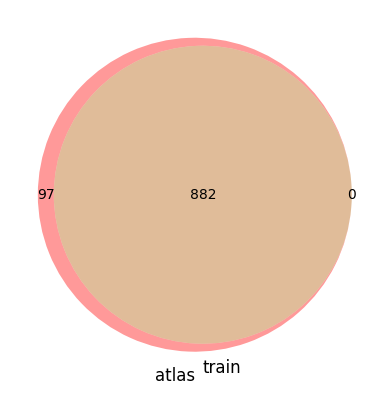

merged sc data and external test dataset with shape (gene, cell): (882, 1194163)
Import data, cell number: 1194163, gene number: 882
After cell threshold: 50, remain adata shape (cell, gene): (1194163, 882)
remain test adata cell num 312995
Finish normalize per cell, so that every cell has the same total count after normalization.
Finish normalize per gene as Gaussian-dist (0, 1).


/mnt/yijun/nfs_share/miniconda3/lib/python3.10/site-packages/anndata/utils.py:143: UserWarning: X converted to numpy array with dtype float64
  warnings.warn(f"{name} converted to numpy array with dtype {arr.dtype}")
/mnt/yijun/nfs_share/yijun_tmp/ipykernel_3605650/2850224853.py:28: FutureWarning: X.dtype being converted to np.float32 from float64. In the next version of anndata (0.9) conversion will not be automatic. Pass dtype explicitly to avoid this warning. Pass `AnnData(X, dtype=X.dtype, ...)` to get the future behavour.
  query_adata = ad.AnnData(X=trainData_renormalized_df, obs=train_cell_info_df)


get query adata AnnData object with n_obs × n_vars = 312995 × 979
    obs: 'donor', 'celltype_update', 'day', 'time', 'cell_id'


In [5]:
# --------------------------------preprocess on query data-----------------------------------------
gene_dic = geneId_geneName_dic()
try:
    query_adata_raw = ad.read_csv(f"{data_golbal_path}/{query_data_path}/data_count_hvg.csv", delimiter='\t')
except:
    query_adata_raw = ad.read_csv(f"{data_golbal_path}/{query_data_path}/data_count_hvg.csv", delimiter=',')
cell_time_query_pd = pd.read_csv(f"{data_golbal_path}/{query_data_path}/cell_with_time.csv", sep="\t", index_col=0)
query_adata_raw = query_adata_raw.copy().T
query_adata_raw.obs = cell_time_query_pd

# 计算每个细胞类型的数量
celltype_counts = query_adata_raw.obs["celltype_update"].value_counts()
print(f"plot for {len(query_adata_raw)} cells")
if len(celltype_counts) > 10:
    # 选出数量前10的细胞类型
    top_10_attr = celltype_counts.head(10).index.tolist()
    # 根据选出的前10细胞类型筛选adata
    query_adata_raw = query_adata_raw[query_adata_raw.obs["celltype_update"].isin(top_10_attr)].copy()
    print(f"plot for celltype_update, as the number is more than 10, select top 10 to plot umap: {top_10_attr}, the cell is filtered to {len(query_adata_raw)}")
    cell_time_query_pd = cell_time_query_pd[cell_time_query_pd["celltype_update"].isin(top_10_attr)]
    cell_time_query_pd = cell_time_query_pd.loc[query_adata_raw.obs.index]
trainData_renormalized_df, loss_gene_shortName_list, train_cell_info_df = predict_newData_preprocess_df(
    gene_dic, query_adata_raw,
    min_gene_num=min_gene_num,
    mouse_atlas_file=f"{data_golbal_path}/{baseline_data_path}/data_count_hvg.csv",
    bool_change_geneID_to_geneShortName=False
)
query_adata = ad.AnnData(X=trainData_renormalized_df, obs=train_cell_info_df)
print(f"get query adata {query_adata}")

### preprocess on baseline data

In [6]:
# ------------------------------preprocess on baseline data----------------------------------------------------------
atlas_sc_expression_df, cell_time_atlas = preprocessData_and_dropout_some_donor_or_gene(data_golbal_path,
                                                                                        f"{baseline_data_path}/data_count_hvg.csv",
                                                                                        f"{baseline_data_path}/cell_with_time.csv",
                                                                                        min_cell_num=50,
                                                                                        min_gene_num=100)

2024-05-09 07:38:29,905 INFO - utils.utils_DandanProject - the original sc expression anndata should be gene as row, cell as column 
2024-05-09 07:40:49,541 INFO - utils.utils_DandanProject - read the original sc expression anndata with shape (gene, cell): (979, 881168) 
2024-05-09 07:40:49,554 INFO - utils.utils_DandanProject - Import data, cell number: 881168, gene number: 979 
2024-05-09 07:41:02,890 INFO - utils.utils_DandanProject - After drop gene threshold: 50, cell threshold: 100, remain adata shape: (881168, 979) 
2024-05-09 07:41:02,891 INFO - utils.utils_DandanProject - Drop cells with less than 100 gene expression, drop genes which none expression in 50 samples 
2024-05-09 07:41:02,891 INFO - utils.utils_DandanProject - After filter, get cell number: 881168, gene number: 979 
2024-05-09 07:41:10,347 INFO - utils.utils_DandanProject - Finish normalize per cell to 1000000.0, so that every cell has the same total count after normalization. 
2024-05-09 07:41:27,975 INFO - utils

### use TemporalVAE model(trained by baseline dataset) to predict on query dataset

Free Memory Percentage: 46.96%
[INFO] GPU device 2 - total: 40.0GB; - memory free: 32.581GB.
[INFO] GPU device 1 - total: 40.0GB; - memory free: 38.257GB.
[INFO] GPU device 0 - total: 40.0GB; - memory free: 24.899GB.

[INFO] more than 5% free memory, Auto select GPU device 1,- memory free: 38.257GB


2024-05-09 07:41:34,700 INFO - torch.distributed.nn.jit.instantiator - Created a temporary directory at /mnt/yijun/nfs_share/yijun_tmp/tmpplzrsb2f 
2024-05-09 07:41:34,702 INFO - torch.distributed.nn.jit.instantiator - Writing /mnt/yijun/nfs_share/yijun_tmp/tmpplzrsb2f/_remote_module_non_scriptable.py 
2024-05-09 07:41:35,035 INFO - pytorch_lightning.utilities.rank_zero - GPU available: True (cuda), used: True 
2024-05-09 07:41:35,036 INFO - pytorch_lightning.utilities.rank_zero - TPU available: False, using: 0 TPU cores 
2024-05-09 07:41:35,036 INFO - pytorch_lightning.utilities.rank_zero - IPU available: False, using: 0 IPUs 
2024-05-09 07:41:35,037 INFO - pytorch_lightning.utilities.rank_zero - HPU available: False, using: 0 HPUs 
2024-05-09 07:41:35,038 INFO - lightning_fabric.utilities.seed - Global seed set to 1265 
2024-05-09 07:41:37,851 INFO - pytorch_lightning.accelerators.cuda - LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2] 
2024-05-09 20:41:38.331695: I tensorflow/core/plat

Predicting: 0it [00:00, ?it/s]

=== data correlation: 
Spearman correlation=0.67361, p-value=0.00000; 
Pearson correlation=0.73413, p-value=0.00000; 
Kendall correlation=0.52953, p-value=0.00000; 
R-squared=0.11960.


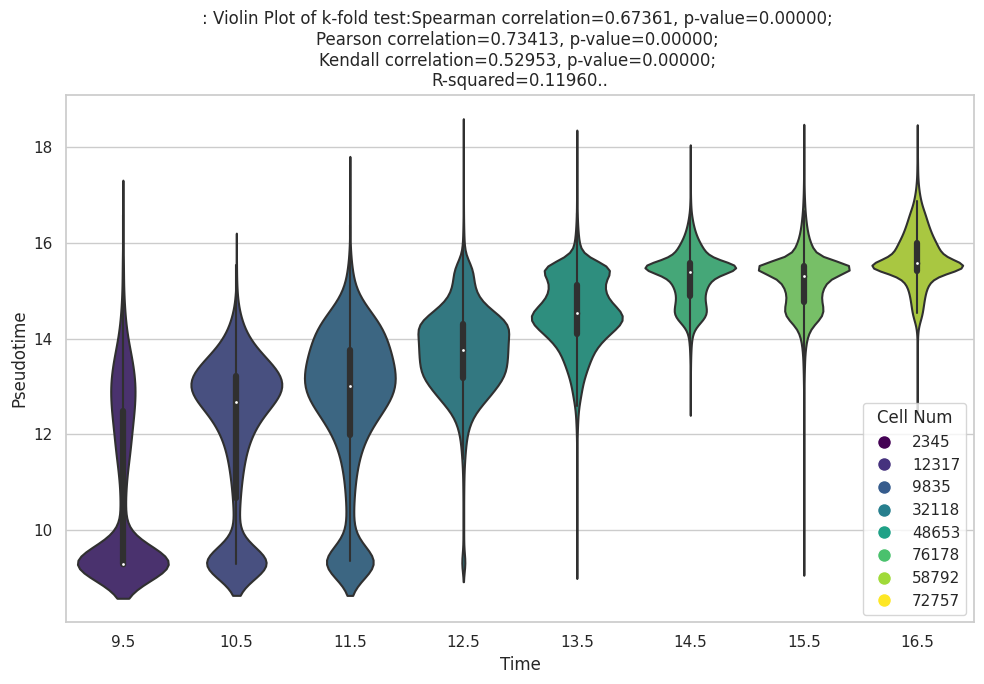

... storing 'donor' as categorical
... storing 'celltype_update' as categorical
... storing 'day' as categorical


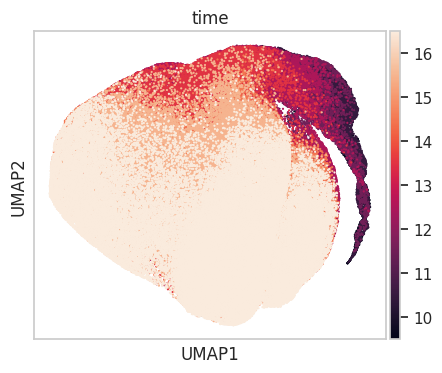

save at results/Figure3_LR_PCA_RF_directlyPredictOn_mouseStereo_minGeneNum50/


... storing 'donor' as categorical
... storing 'celltype_update' as categorical
... storing 'day' as categorical
/mnt/yijun/nfs_share/miniconda3/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


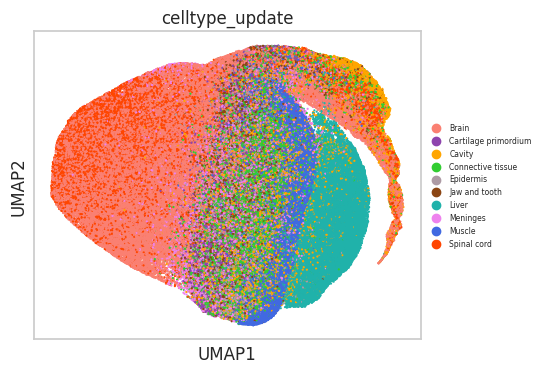

save at results/Figure3_LR_PCA_RF_directlyPredictOn_mouseStereo_minGeneNum50/
Final corr: Spearman correlation=0.67361, p-value=0.00000; 
Pearson correlation=0.73413, p-value=0.00000; 
Kendall correlation=0.52953, p-value=0.00000; 
R-squared=0.50051.
test result save at results/Figure3_LR_PCA_RF_directlyPredictOn_mouseStereo_minGeneNum50//temporalVAE_result_df.csv


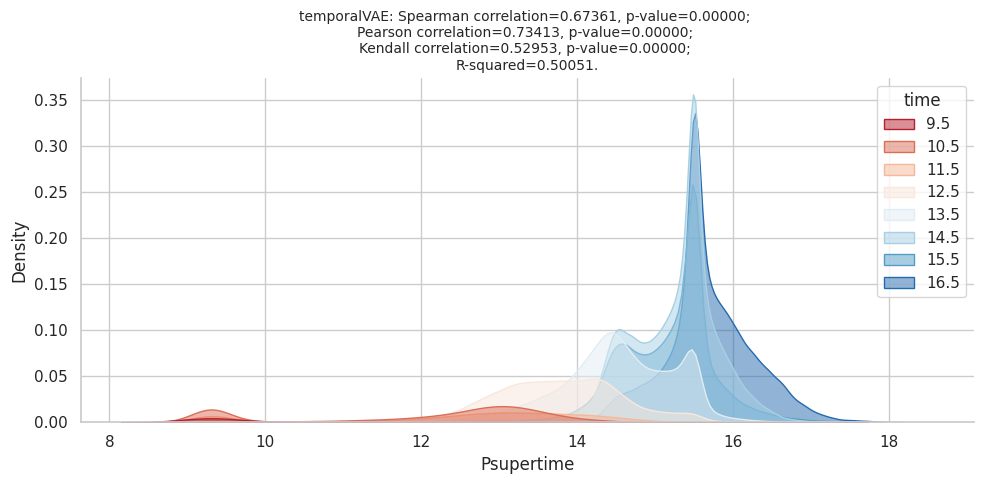

figure save at results/Figure3_LR_PCA_RF_directlyPredictOn_mouseStereo_minGeneNum50//temporalVAE_labelsOverPsupertime.png
Finish temporalVAE train on baseline data and predict on query data.


In [7]:
directly_predict_on_vae(query_adata, save_path, checkpoint_file, config)

### train a LR model by baseline dataset, then predict on query dataset

/mnt/yijun/nfs_share/yijun_tmp/ipykernel_3605650/682379054.py:111: FutureWarning: X.dtype being converted to np.float32 from float64. In the next version of anndata (0.9) conversion will not be automatic. Pass dtype explicitly to avoid this warning. Pass `AnnData(X, dtype=X.dtype, ...)` to get the future behavour.
  adata_atlas = ad.AnnData(X=atlas_sc_expression_df, obs=cell_time_atlas)


Final corr: Spearman correlation=0.60220, p-value=0.00000; 
Pearson correlation=0.62371, p-value=0.00000; 
Kendall correlation=0.46079, p-value=0.00000; 
R-squared=0.38571.
test result save at results/Figure3_LR_PCA_RF_directlyPredictOn_mouseStereo_minGeneNum50//linearRegression_result_df.csv


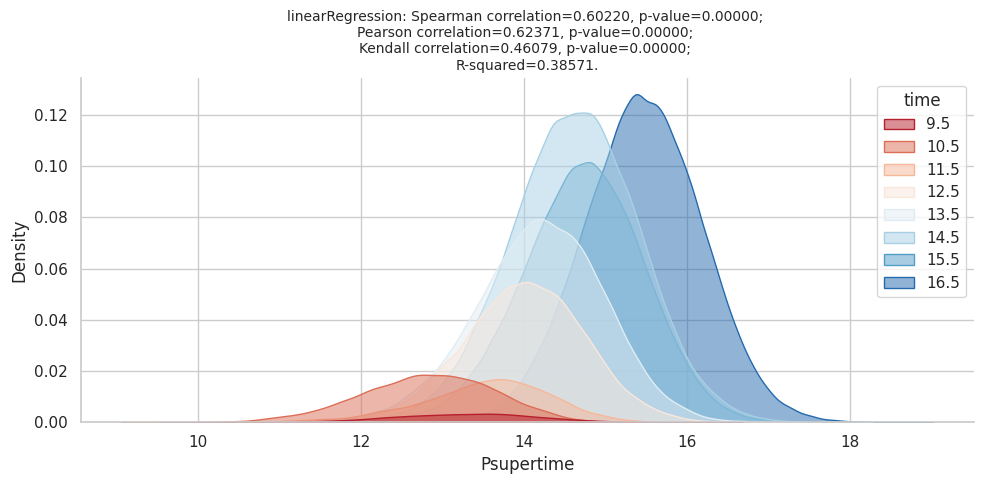

figure save at results/Figure3_LR_PCA_RF_directlyPredictOn_mouseStereo_minGeneNum50//linearRegression_labelsOverPsupertime.png
Finish linearRegression train on baseline data and predict on query data.


In [8]:
train_LR_model(atlas_sc_expression_df, cell_time_atlas, query_adata, save_path)

### train a PCA model by baseline dataset, then predict on query dataset

/mnt/yijun/nfs_share/yijun_tmp/ipykernel_3605650/682379054.py:155: FutureWarning: X.dtype being converted to np.float32 from float64. In the next version of anndata (0.9) conversion will not be automatic. Pass dtype explicitly to avoid this warning. Pass `AnnData(X, dtype=X.dtype, ...)` to get the future behavour.
  adata_atlas = ad.AnnData(X=atlas_sc_expression_df, obs=cell_time_atlas)


Final corr: Spearman correlation=0.07389, p-value=0.00000; 
Pearson correlation=-0.00090, p-value=0.61471; 
Kendall correlation=0.05035, p-value=0.00000; 
R-squared=-49.67328.
test result save at results/Figure3_LR_PCA_RF_directlyPredictOn_mouseStereo_minGeneNum50//PCAresult_df.csv


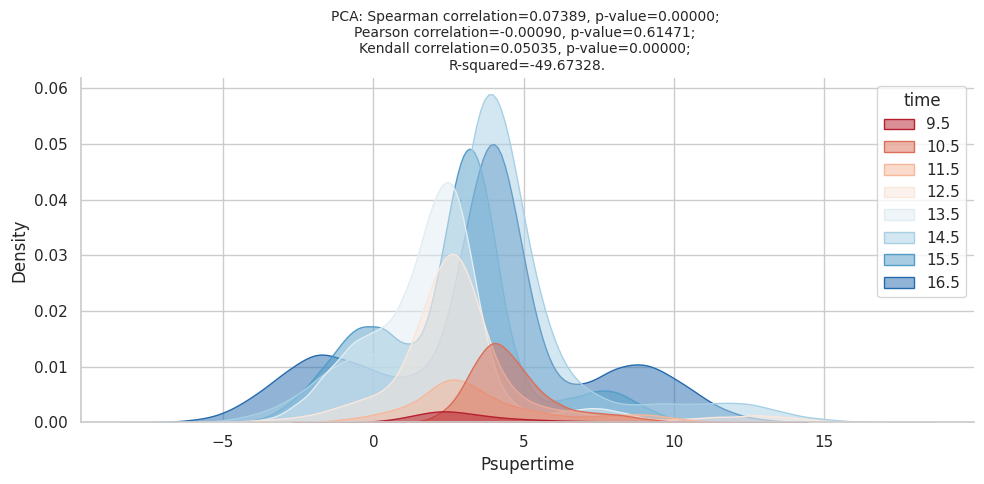

figure save at results/Figure3_LR_PCA_RF_directlyPredictOn_mouseStereo_minGeneNum50//PCA_labelsOverPsupertime.png
Finish PCA train on baseline data and predict on query data.


In [9]:
train_PCA_model(atlas_sc_expression_df, cell_time_atlas, query_adata, save_path)

### train a RF model by baseline dataset, then predict on query dataset

/mnt/yijun/nfs_share/yijun_tmp/ipykernel_3605650/682379054.py:132: FutureWarning: X.dtype being converted to np.float32 from float64. In the next version of anndata (0.9) conversion will not be automatic. Pass dtype explicitly to avoid this warning. Pass `AnnData(X, dtype=X.dtype, ...)` to get the future behavour.
  adata_atlas = ad.AnnData(X=atlas_sc_expression_df, obs=cell_time_atlas)
/mnt/yijun/nfs_share/miniconda3/lib/python3.10/site-packages/scipy/stats/_stats_py.py:5278: RuntimeWarning: overflow encountered in scalar multiply
  (2 * xtie * ytie) / m + x0 * y0 / (9 * m * (size - 2)))


Final corr: Spearman correlation=-0.11432, p-value=0.00000; 
Pearson correlation=-0.11004, p-value=0.00000; 
Kendall correlation=-0.10144, p-value=0.00000; 
R-squared=-0.84818.
test result save at results/Figure3_LR_PCA_RF_directlyPredictOn_mouseStereo_minGeneNum50//randomForest_result_df.csv


/mnt/yijun/nfs_share/miniconda3/lib/python3.10/site-packages/scipy/stats/_stats_py.py:5278: RuntimeWarning: overflow encountered in scalar multiply
  (2 * xtie * ytie) / m + x0 * y0 / (9 * m * (size - 2)))


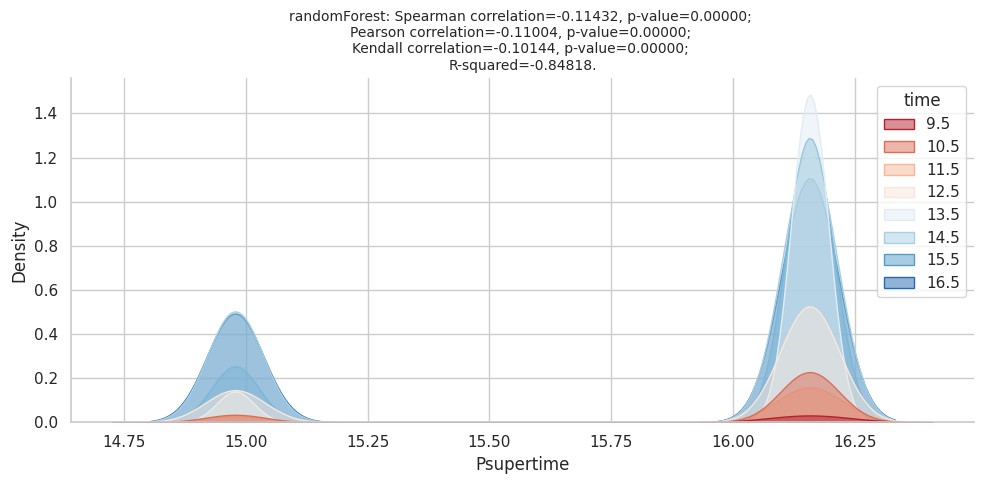

figure save at results/Figure3_LR_PCA_RF_directlyPredictOn_mouseStereo_minGeneNum50//randomForest_labelsOverPsupertime.png
Finish randomForest train on baseline data and predict on query data.


In [10]:
train_RF_model(atlas_sc_expression_df, cell_time_atlas, query_adata, save_path)

### plot Figure3 E

/mnt/yijun/nfs_share/miniconda3/lib/python3.10/site-packages/scipy/stats/_stats_py.py:5278: RuntimeWarning: overflow encountered in scalar multiply
  (2 * xtie * ytie) / m + x0 * y0 / (9 * m * (size - 2)))


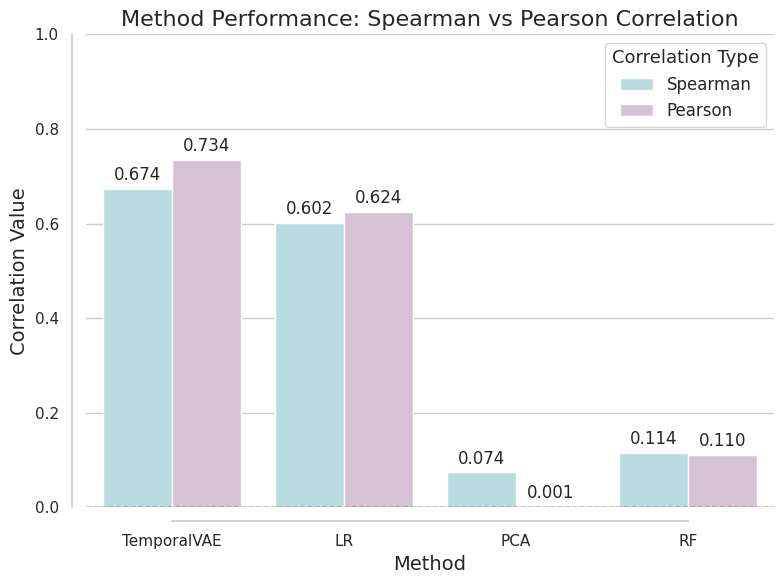

In [11]:
plot_compare_corr_boxplot(save_path)